## Visualize HWiNFO data

This notebook is used to visualize the HWiNFO data collected during the 10-minute test run using Cinebench 2026.

Three configurations were tested:

- Laptop on a flat surface.
- Lifted laptop.
- Laptop on the Flydigi BS2 cooling pad.

We combine the data from all three configurations in this notebook to compare the CPU package temperature across the different configurations.

### Load data

Let's start by loading the data.

In [1]:
import pandas as pd

paths = [
    "../data/cinebench_on_floor.csv",
    "../data/cinebench_lifted.csv",
    "../data/cinebench_flydigi_bs2.csv",
]

dfs = {}
for path in paths:
    df = pd.read_csv(filepath_or_buffer=path, encoding="iso-8859-1", low_memory=False)
    df = df[:-2]

    key = path.split("/")[-1].split(".")[0]
    dfs[key] = df
    print(f"Loaded {key}.csv with shape {df.shape}")

Loaded cinebench_on_floor.csv with shape (324, 509)
Loaded cinebench_lifted.csv with shape (324, 509)
Loaded cinebench_flydigi_bs2.csv with shape (322, 509)


### Select columns of interest

HWiNFO collects a lot of data, but we are only interested in a few columns for our analysis.

In [2]:
useful_columns = [
    "Date",
    "Time",
    "CPU Package [°C]",
    "GPU Temperature [°C]",
    "CPU Package Power [W]",
    "GPU Power [W]",
    "P-core 0 Clock [MHz]",
    "GPU Clock [MHz]",
]

for key, df in dfs.items():
    clean_df = df[useful_columns].copy()
    dfs[key] = clean_df
    print(f"Cleaned {key}.csv with shape {clean_df.shape}")

Cleaned cinebench_on_floor.csv with shape (324, 8)
Cleaned cinebench_lifted.csv with shape (324, 8)
Cleaned cinebench_flydigi_bs2.csv with shape (322, 8)


### Compute new columns

Merge the "Date" and "Time" columns into a single "DateTime" column.

In [3]:
for key, df in dfs.items():
    df["DateTime"] = df["Date"] + " " + df["Time"]
    df["DateTime"] = pd.to_datetime(
        arg=df["DateTime"],
        format="%d.%m.%Y %H:%M:%S.%f",
        errors="coerce",
    )
    dfs[key] = df
    print(f"Parsed DateTime for {key}.csv with shape {df.shape}")

Parsed DateTime for cinebench_on_floor.csv with shape (324, 9)
Parsed DateTime for cinebench_lifted.csv with shape (324, 9)
Parsed DateTime for cinebench_flydigi_bs2.csv with shape (322, 9)


Calculate the "Minutes" column, which represents the time in minutes since the start of the experiment.

In [4]:
for key, df in dfs.items():
    print(f"Original shape : {df.shape}")
    start_datetime = df["DateTime"].iloc[0]
    time_diff = df["DateTime"] - start_datetime
    df["Minutes"] = time_diff.dt.total_seconds() / 60
    print(f"New shape      : {df.shape}")
    print()

Original shape : (324, 9)
New shape      : (324, 10)

Original shape : (324, 9)
New shape      : (324, 10)

Original shape : (322, 9)
New shape      : (322, 10)



### Cast columns to appropriate data types

Let's first see if we have missing values in our cleaned DataFrame.

In [5]:
for key, df in dfs.items():
    missing_values = df.isnull().sum().sum()
    missing_percentage = (missing_values / df.size) * 100
    print(f"Missing values in {key}.csv: {missing_values} ({missing_percentage:.2f}%)")

Missing values in cinebench_on_floor.csv: 0 (0.00%)
Missing values in cinebench_lifted.csv: 0 (0.00%)
Missing values in cinebench_flydigi_bs2.csv: 0 (0.00%)


"DateTime" and "Minutes" have correct data types, but the other columns are of type "object", which means they are currently treated as strings.

We will need to convert them to numeric data types for our analysis.

In [6]:
useful_columns

['Date',
 'Time',
 'CPU Package [°C]',
 'GPU Temperature [°C]',
 'CPU Package Power [W]',
 'GPU Power [W]',
 'P-core 0 Clock [MHz]',
 'GPU Clock [MHz]']

Drop the "Date" and "Time" columns and create a new set of numeric columns.

In [7]:
numeric_columns = list(set(useful_columns) - {"Date", "Time"})
print("\n".join(numeric_columns))

CPU Package Power [W]
GPU Power [W]
GPU Clock [MHz]
CPU Package [°C]
GPU Temperature [°C]
P-core 0 Clock [MHz]


In [8]:
for key, df in dfs.items():
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    dfs[key] = df
    print(f"Converted numeric columns for {key}.csv with shape {df.shape}")

Converted numeric columns for cinebench_on_floor.csv with shape (324, 10)
Converted numeric columns for cinebench_lifted.csv with shape (324, 10)
Converted numeric columns for cinebench_flydigi_bs2.csv with shape (322, 10)


Let's verify the data types of the columns after conversion.

In [9]:
for key, df in dfs.items():
    print(f"Data types for {key}.csv:")
    print(df.dtypes)
    print()

Data types for cinebench_on_floor.csv:
Date                             object
Time                             object
CPU Package [°C]                  int64
GPU Temperature [°C]            float64
CPU Package Power [W]           float64
GPU Power [W]                   float64
P-core 0 Clock [MHz]            float64
GPU Clock [MHz]                 float64
DateTime                 datetime64[ns]
Minutes                         float64
dtype: object

Data types for cinebench_lifted.csv:
Date                             object
Time                             object
CPU Package [°C]                  int64
GPU Temperature [°C]            float64
CPU Package Power [W]           float64
GPU Power [W]                   float64
P-core 0 Clock [MHz]            float64
GPU Clock [MHz]                 float64
DateTime                 datetime64[ns]
Minutes                         float64
dtype: object

Data types for cinebench_flydigi_bs2.csv:
Date                             object
Time        

### Visualize the data

Configure Jupyter to display plots in `SVG` format for better quality.

In [10]:
%config InlineBackend.figure_format = 'svg'

Let's visualize the CPU package temperature over time.

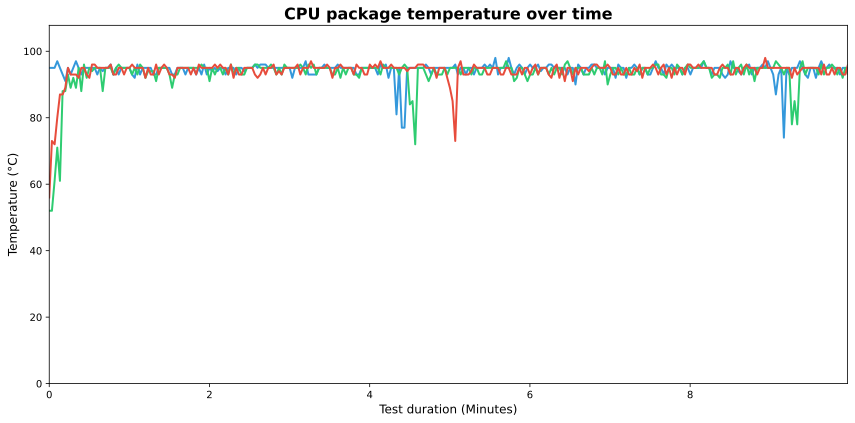

In [11]:
import matplotlib.pyplot as plt

figure_size = (12, 6)
column_to_plot = "CPU Package [°C]"

colors = {
    "cinebench_on_floor": "#3498db",
    "cinebench_lifted": "#2ecc71",
    "cinebench_flydigi_bs2": "#e74c3c",
}

plt.figure(figsize=figure_size)

for key, df in dfs.items():
    plt.plot(
        df["Minutes"],
        df[column_to_plot],
        label=key.replace("_", " ").title(),
        color=colors[key],
        linewidth=2,
    )

plt.title(
    label="CPU package temperature over time",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Test duration (Minutes)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)

plt.xlim(0, max(df["Minutes"].max() for df in dfs.values()) * 0.9)
plt.ylim(0, max(df[column_to_plot].max() for df in dfs.values()) * 1.1)

plt.tight_layout()

image_folder = "../images/cinebench_combined"
plt.savefig(f"{image_folder}/cpu_package_temperature.svg", format="svg")
plt.show()

If you find the data too noisy, you can smooth it using a rolling average.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

figure_size = (12, 6)
column_to_plot = "CPU Package [°C]"

colors = {
    "cinebench_on_floor": "#3498db",
    "cinebench_lifted": "#2ecc71",
    "cinebench_flydigi_bs2": "#e74c3c",
}

plt.figure(figsize=figure_size)

num_steps = 50

for key, df in dfs.items():
    smoothed_values = df[column_to_plot].rolling(window=10, min_periods=1).mean()
    y_values = smoothed_values.to_numpy()
    x_values = df["Minutes"].to_numpy()
    color = colors[key]

    plt.plot(
        x_values,
        y_values,
        label=key.replace("_", " ").capitalize(),
        color=color,
        linewidth=2,
        zorder=5,
    )

    y_steps = np.linspace(20, y_values, num_steps)
    for i in range(num_steps - 1):
        alpha_level = (i / num_steps) * 0.1
        plt.fill_between(
            x_values,
            y_steps[i],
            y_steps[i + 1],
            color=color,
            alpha=alpha_level,
            linewidth=0,
            zorder=2,
        )

plt.title(
    label="CPU package temperature (smoothed) over time",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Test duration (Minutes)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)

plt.xlim(0, max(df["Minutes"].max() for df in dfs.values()) * 0.9)
plt.ylim(0, max(df[column_to_plot].max() for df in dfs.values()) * 1.1)

plt.legend()
plt.tight_layout()

image_folder = "../images/cinebench_combined"
plt.savefig(f"{image_folder}/cpu_package_temperature_smoothed.svg", format="svg")
plt.show()